In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [6]:
data = pd.read_csv('student_performance_dataset.csv', encoding='unicode_escape')

In [7]:
#data cleaning

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 93.9 KB


In [10]:
#Here we have some empty cells for parental_education

In [11]:
data['parental_education'].unique()

<StringArray>
['Bachelors', 'High School', nan, 'Masters', 'PhD']
Length: 5, dtype: str

In [12]:
data['parental_eduacation']=data['parental_education'].fillna('none')

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
 12  parental_eduacation         1000 non-null   str    
dtypes: float64(5), int64(1), str(7)
memory usage:

In [14]:
data['parental_education'].value_counts()

parental_education
High School    356
Bachelors      308
Masters        184
PhD             50
Name: count, dtype: int64

In [16]:
data['parental_education'].fillna('None', inplace=True)

C:\Users\grvad\AppData\Local\Temp\ipykernel_16984\3249741577.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['parental_education'].fillna('None', inplace=True)


0        Bachelors
1      High School
2        Bachelors
3             None
4        Bachelors
          ...     
995        Masters
996           None
997    High School
998    High School
999        Masters
Name: parental_education, Length: 1000, dtype: str

In [17]:
print(data['parental_education'].isna().sum())

102


In [18]:
data['parental_education'] = data['parental_education'].fillna('None')

In [19]:
data['parental_education'].value_counts()

parental_education
High School    356
Bachelors      308
Masters        184
None           102
PhD             50
Name: count, dtype: int64

In [20]:
#Now we have replaced the null data with the None value


In [21]:
data['parental_education'].info()

<class 'pandas.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: parental_education
Non-Null Count  Dtype
--------------  -----
1000 non-null   str  
dtypes: str(1)
memory usage: 7.9 KB


In [22]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          1000 non-null   str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
 12  parental_eduacation         1000 non-null   str    
dtypes: float64(5), int64(1), str(7)
memory usage:

In [24]:
#Now We have completed the data cleaning, We need to sketch the graph with final_grade and parental_eductaion relation.

In [26]:
data['final_grade'].unique()


<StringArray>
['A', 'B', 'D', 'C', 'F']
Length: 5, dtype: str

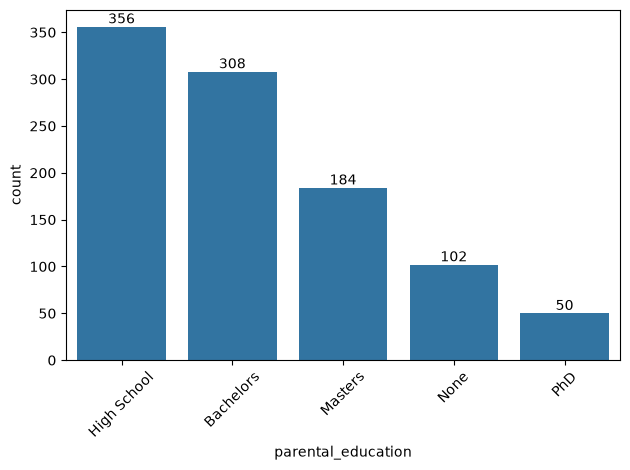

In [30]:
order = data['parental_education'].value_counts().index
ax = sns.countplot(
    data=data,
    x='parental_education',
    order=order
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
#Above we see Most of the parents are from high school and only few have done PhD

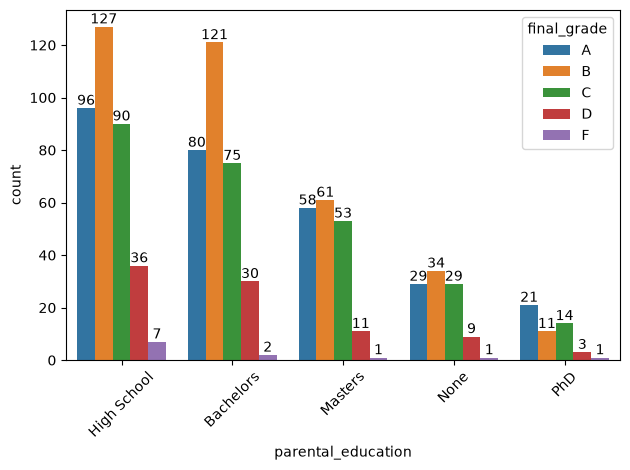

In [36]:
order = data['parental_education'].value_counts().index
ax = sns.countplot(
    data=data,
    x='parental_education',
    order=order,
    hue='final_grade',
    hue_order=['A', 'B', 'C', 'D', 'F']

)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
percentage = (
    data.groupby('parental_education')['final_grade']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index(name='percentage')
)

percentage['parental_education'] = pd.Categorical(
    percentage['parental_education'],
    categories=['None', 'High School', 'Bachelors', 'Masters', 'PhD'],
    ordered=True
)
percentage = percentage.sort_values(
    ['parental_education', 'final_grade']
)
print(percentage)

   parental_education final_grade  percentage
17               None           A   28.431373
15               None           B   33.333333
16               None           C   28.431373
18               None           D    8.823529
19               None           F    0.980392
6         High School           A   26.966292
5         High School           B   35.674157
7         High School           C   25.280899
8         High School           D   10.112360
9         High School           F    1.966292
1           Bachelors           A   25.974026
0           Bachelors           B   39.285714
2           Bachelors           C   24.350649
3           Bachelors           D    9.740260
4           Bachelors           F    0.649351
11            Masters           A   31.521739
10            Masters           B   33.152174
12            Masters           C   28.804348
13            Masters           D    5.978261
14            Masters           F    0.543478
20                PhD           A 

In [42]:
#Here from above analysis,We found out the students with parents of High School have bad grades.

In [43]:
#Also we found out the lesser parents are higher education background

In [44]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          1000 non-null   str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
 12  parental_eduacation         1000 non-null   str    
dtypes: float64(5), int64(1), str(7)
memory usage:

In [46]:
data['study_time_hours'].unique()

array([4. , 6.3, 4.9, 2.6, 2.2, 4.2, 1.5, 6.2, 5.3, 2.8, 0.9, 5.5, 3.3,
       5.4, 1.1, 3.5, 3.6, 4.4, 1.9, 3.7, 4.3, 4.6, 1.8, 1.2, 2.4, 5.8,
       6.6, 6.1, 3.1, 5. , 4.5, 5.6, 2.1, 5.1, 1.7, 0.5, 5.9, 1.4, 3.4,
       4.1, 2.7, 2. , 2.3, 6.4, 2.5, 3.8, 3.2, 6. , 8.1, 5.2, 4.8, 5.7,
       3.9, 1. , 0.8, 2.9, 3. , 0.7, 4.7, 1.3, 6.9, 1.6, 7.2, 7.4, 7.3,
       6.5, 6.7, 7.1, 6.8, 7. ])

In [47]:
data['grade_category'] = data['final_grade'].map({
    'A': 'Good',
    'B': 'Good',
    'C': 'Average',
    'D': 'Poor',
    'F': 'Poor'
})

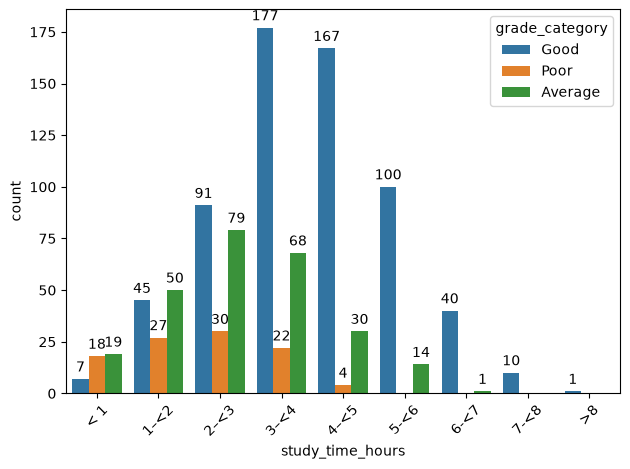

In [51]:
ax=sns.countplot(
    data=data,
    x=pd.cut(
        data['study_time_hours'],
        bins=[-float('inf'), 1, 2, 3, 4, 5,6,7,8,9],
        labels=['< 1', '1–<2', '2–<3', '3–<4', '4–<5','5-<6','6-<7','7-<8','>8']
    ),
   hue='grade_category'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

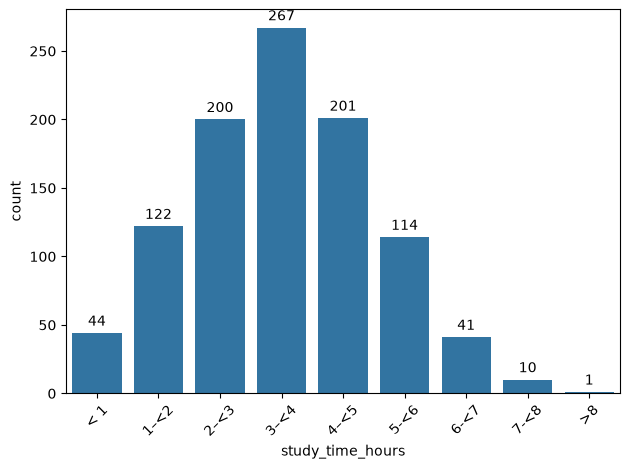

In [52]:
ax=sns.countplot(
    data=data,
    x=pd.cut(
        data['study_time_hours'],
        bins=[-float('inf'), 1, 2, 3, 4, 5,6,7,8,9],
        labels=['< 1', '1–<2', '2–<3', '3–<4', '4–<5','5-<6','6-<7','7-<8','>8']
    ),
)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
#The above graphs shows there are students studying less than 4 hours a data which is bare minimum for students.

In [54]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          1000 non-null   str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
 12  parental_eduacation         1000 non-null   str    
 13  grade_category              1000 non-null   s

In [55]:
#As we know all these data are of high school students 10.

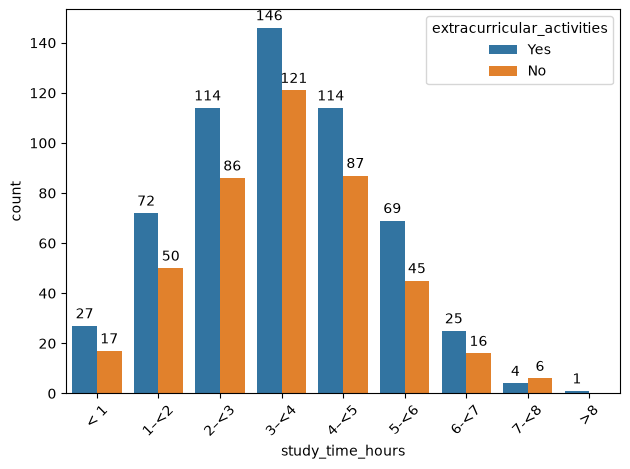

In [56]:
ax=sns.countplot(
    data=data,
    x=pd.cut(
        data['study_time_hours'],
        bins=[-float('inf'), 1, 2, 3, 4, 5,6,7,8,9],
        labels=['< 1', '1–<2', '2–<3', '3–<4', '4–<5','5-<6','6-<7','7-<8','>8']
    ),
   hue='extracurricular_activities'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

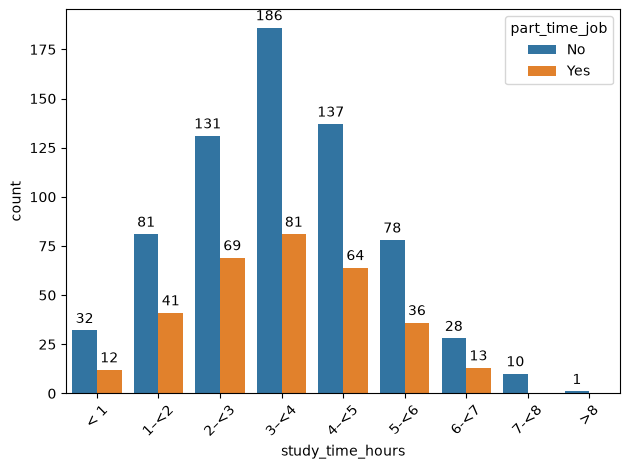

In [58]:
ax=sns.countplot(
    data=data,
    x=pd.cut(
        data['study_time_hours'],
        bins=[-float('inf'), 1, 2, 3, 4, 5,6,7,8,9],
        labels=['< 1', '1–<2', '2–<3', '3–<4', '4–<5','5-<6','6-<7','7-<8','>8']
    ),
   hue='part_time_job'
)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
#Above two graphs shows most of the student who are doing a part time jobs and extra curricular activities are studyong less hours 

In [60]:
#Generally are those we are doing part time jobs.

In [61]:
#Now lets see the data for the students doing part time jobs, extra_curricular activities and their grade categories. 

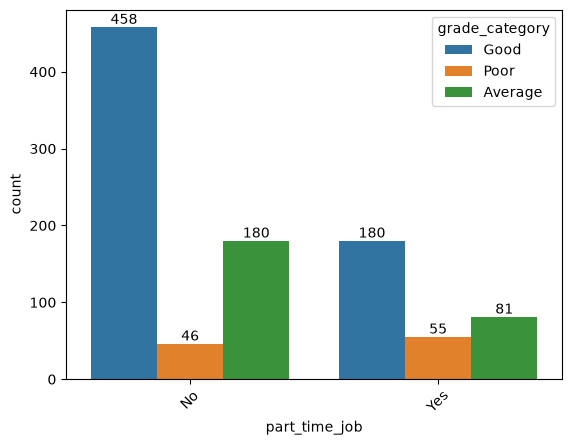

In [62]:
ax= sns.countplot(
    data=data,
    x='part_time_job',
    hue= 'grade_category'
)
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation =45)
plt.show()

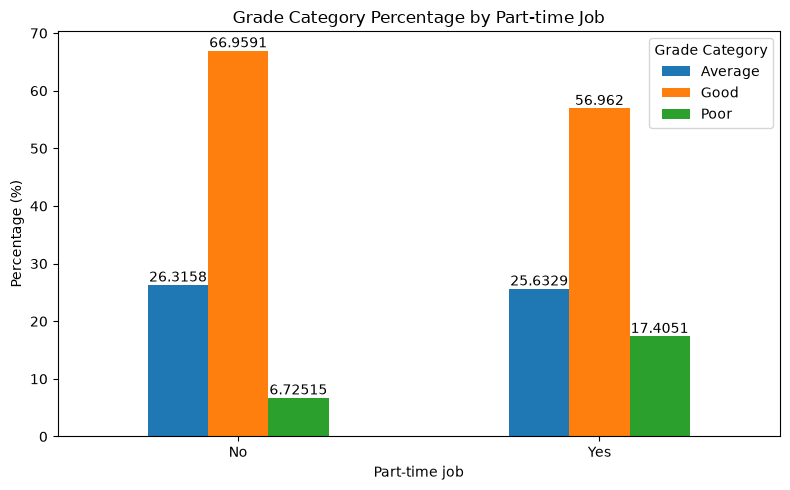

In [64]:

percentage = pd.crosstab(
    data['part_time_job'],
    data['grade_category'],
    normalize='index',
    
) * 100

ax = percentage.plot(
    kind='bar',
    figsize=(8, 5)
)

ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Part-time job')
ax.set_title('Grade Category Percentage by Part-time Job')

for container in ax.containers:
    ax.bar_label(container)
    
plt.xticks(rotation=0)
plt.legend(title='Grade Category')
plt.tight_layout()
plt.sortvalues()
plt.show()

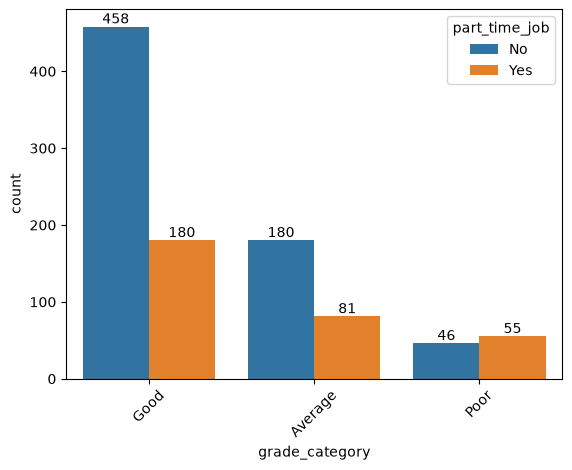

In [67]:
ax= sns.countplot(
    data=data,
    x='grade_category',
    hue= 'part_time_job',
    order=['Good','Average','Poor']
)
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation =45)
plt.show()

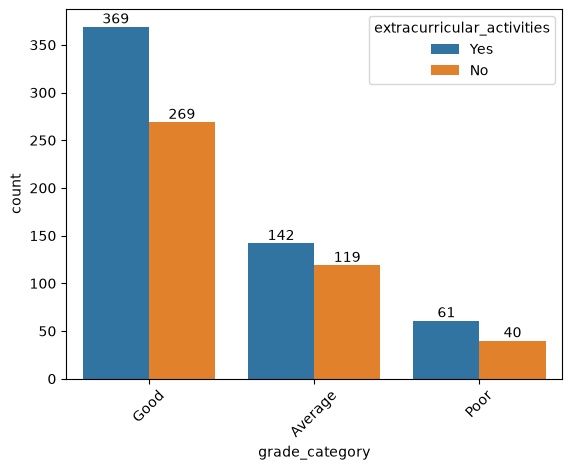

In [69]:
ax= sns.countplot(
    data=data,
    x='grade_category',
    hue= 'extracurricular_activities',
    order=['Good','Average','Poor']
)
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation =45)
plt.show()

In [70]:
#Here We have analyzed that the student with average and poor categories grade have almost similar distribution of participating in extracuricular

In [71]:
# Despite participating in extracuricular, most of the students have good results.
#Also, Most of the students are not participating yet on part_time_jobs. 56% of student doing part time job are good at studies.
#Hence dropping only by 10% to not doing part-time jobs. Showing proficiency of practical and extra activities which may not hamper the studies.


In [76]:
#Now,We need to shortlist the students who are doing the part time jobs, to recommend them for open class of our institution and if they have good
# grades We may recommend them science stream else recommending non-science stream.

In [75]:
#If they are both into extra curricular and part time job , We will recommend them  extra_curricular subject and open class.

In [81]:
#data with part time job and good marks
df1 = data[
    (data['grade_category'] == 'Good') &
    (data['part_time_job'] == 'Yes')     
]
df1.info()

<class 'pandas.DataFrame'>
Index: 180 entries, 1 to 998
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  180 non-null    int64  
 1   gender                      180 non-null    str    
 2   study_time_hours            180 non-null    float64
 3   attendance_percent          180 non-null    float64
 4   sleep_hours                 180 non-null    float64
 5   parental_education          180 non-null    str    
 6   internet_access             180 non-null    str    
 7   extracurricular_activities  180 non-null    str    
 8   part_time_job               180 non-null    str    
 9   previous_grade              180 non-null    float64
 10  final_exam_score            180 non-null    float64
 11  final_grade                 180 non-null    str    
 12  parental_eduacation         180 non-null    str    
 13  grade_category              180 non-null    str    

In [82]:
print(df1[['student_id','gender','part_time_job','previous_grade','extracurricular_activities','grade_category']])

     student_id  gender part_time_job  previous_grade  \
1             2  Female           Yes            75.5   
2             3    Male           Yes            88.5   
12           13    Male           Yes            49.0   
19           20    Male           Yes            77.0   
24           25  Female           Yes            66.6   
..          ...     ...           ...             ...   
956         957  Female           Yes            84.7   
966         967    Male           Yes            63.8   
970         971  Female           Yes            90.7   
989         990  Female           Yes            78.0   
998         999  Female           Yes            52.2   

    extracurricular_activities grade_category  
1                          Yes           Good  
2                           No           Good  
12                         Yes           Good  
19                          No           Good  
24                         Yes           Good  
..                         

In [83]:
df2 = data[
    (data['grade_category'] == 'Good') &
    (data['part_time_job'] == 'Yes') &
    (data['extracurricular_activities']=='Yes')
]
df2.info()
print(df2[['student_id','gender','part_time_job','previous_grade','extracurricular_activities','grade_category']])

<class 'pandas.DataFrame'>
Index: 97 entries, 1 to 970
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  97 non-null     int64  
 1   gender                      97 non-null     str    
 2   study_time_hours            97 non-null     float64
 3   attendance_percent          97 non-null     float64
 4   sleep_hours                 97 non-null     float64
 5   parental_education          97 non-null     str    
 6   internet_access             97 non-null     str    
 7   extracurricular_activities  97 non-null     str    
 8   part_time_job               97 non-null     str    
 9   previous_grade              97 non-null     float64
 10  final_exam_score            97 non-null     float64
 11  final_grade                 97 non-null     str    
 12  parental_eduacation         97 non-null     str    
 13  grade_category              97 non-null     str    


In [85]:
df3= data[
    (data['grade_category']=='Average') &
    (data['part_time_job']=='Yes')]
print(df3[['student_id','gender','part_time_job','previous_grade','extracurricular_activities','grade_category']])

     student_id  gender part_time_job  previous_grade  \
14           15  Female           Yes            71.0   
17           18  Female           Yes            60.2   
26           27  Female           Yes            68.7   
40           41    Male           Yes            68.4   
61           62    Male           Yes            55.9   
..          ...     ...           ...             ...   
971         972    Male           Yes            71.5   
973         974    Male           Yes            71.2   
981         982  Female           Yes            98.9   
982         983  Female           Yes            72.6   
997         998  Female           Yes            65.2   

    extracurricular_activities grade_category  
14                         Yes        Average  
17                         Yes        Average  
26                          No        Average  
40                         Yes        Average  
61                         Yes        Average  
..                         

In [87]:
df4= data[
    (data['grade_category']=='Poor') &
    (data['part_time_job']=='Yes')]
print(df4[['student_id','gender','part_time_job','previous_grade','extracurricular_activities','grade_category']])
df4.info()

     student_id  gender part_time_job  previous_grade  \
4             5    Male           Yes            61.8   
6             7    Male           Yes            58.6   
10           11    Male           Yes            73.4   
45           46  Female           Yes            83.9   
46           47  Female           Yes            62.7   
82           83    Male           Yes            55.3   
85           86    Male           Yes            70.0   
98           99  Female           Yes            62.9   
101         102  Female           Yes            75.5   
110         111  Female           Yes            56.8   
127         128    Male           Yes            88.4   
136         137    Male           Yes            55.0   
143         144  Female           Yes            71.5   
147         148    Male           Yes            59.2   
148         149    Male           Yes            62.2   
149         150  Female           Yes            63.4   
205         206    Male        

In [88]:
df1.to_csv('good_part_time.csv', index=False)

In [89]:
df1[['student_id','gender','part_time_job','extracurricular_activities','previous_grade','grade_category']].to_csv('good_part_time1.csv',index=False)

In [90]:
df2[['student_id','gender','part_time_job','extracurricular_activities','previous_grade','grade_category']].to_csv('good_part_time_extra.csv',index=False)

In [91]:
df3[['student_id','gender','part_time_job','extracurricular_activities','previous_grade','grade_category']].to_csv('medium_part_time1.csv',index=False)

In [92]:
df4[['student_id','gender','part_time_job','extracurricular_activities','previous_grade','grade_category']].to_csv('poor_part_time1.csv',index=False)